In [1]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt
import seaborn as sns

TASK 1: Daily Returns & Annualized Return

In [3]:
# Load cleaned NAV data
nav = pd.read_csv('../data/processed/clean_nav.csv', parse_dates=['date'])
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
# Compute daily return per fund
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
# Drop NaN (first row of each fund has no prior value)
nav = nav.dropna(subset=['daily_return'])
# Annualised return per fund
def annualised_return(returns):
 n = len(returns)
 cumulative = (1 + returns).prod()
 return cumulative ** (252 / n) - 1
ann_returns = nav.groupby('amfi_code')['daily_return'].apply(annualised_return).reset_index()
ann_returns.columns = ['amfi_code', 'annualised_return']
nav.to_csv('../data/processed/returns_computed.csv', index=False)
print(nav.head())
print(ann_returns.head(10))

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
   amfi_code  annualised_return
0     100016           0.025435
1     100025           0.042987
2     100033           0.289279
3     101206           0.226265
4     101207           0.076502
5     101208           0.062739
6     102885           0.175404
7     102886           0.011304
8     102887           0.162055
9     118632           0.231161


Task 2 — CAGR for 1yr, 3yr, 5yr

In [5]:

from datetime import datetime, timedelta
ref_date = nav['date'].max() # Most recent date in data
periods = {'1yr': 365, '3yr': 3*365, '5yr': 5*365}
cagr_records = []
for amfi_code, group in nav.groupby('amfi_code'):
 group = group.sort_values('date')
 row = {'amfi_code': amfi_code}
 for label, days in periods.items():
    start_date = ref_date - timedelta(days=days)
    subset = group[group['date'] >= start_date]
    if len(subset) < 20: # Not enough data
        row[f'cagr_{label}'] = np.nan
        continue
    nav_end = subset.iloc[-1]['nav']
    nav_start = subset.iloc[0]['nav']
    years = days / 365
    row[f'cagr_{label}'] = (nav_end / nav_start) ** (1 / years) - 1
 cagr_records.append(row)
cagr_df = pd.DataFrame(cagr_records)
cagr_df.to_csv('../data/processed/cagr_report.csv', index=False)
print(cagr_df.round(4).head(10))

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016   -0.0222    0.0103    0.0253
1     100025    0.0370    0.0390    0.0399
2     100033    0.5323    0.3245    0.2641
3     101206    0.4792    0.2867    0.2041
4     101207   -0.2399   -0.0469    0.0719
5     101208    0.0724    0.0632    0.0571
6     102885    0.2021    0.1964    0.1562
7     102886   -0.1680   -0.0095    0.0080
8     102887    0.1358    0.2477    0.1492
9     118632    0.3398    0.2256    0.2090


Task 3 — Sharpe Ratio

In [6]:
RF_ANNUAL = 0.065 # RBI repo rate proxy
RF_DAILY = RF_ANNUAL / 252
def sharpe_ratio(returns):
    excess = returns - RF_DAILY
    if excess.std() == 0:
        return np.nan
    # Annualise: multiply by sqrt(252)
    return (excess.mean() / excess.std()) * np.sqrt(252)
sharpe = nav.groupby('amfi_code')['daily_return'].apply(sharpe_ratio).reset_index()
sharpe.columns = ['amfi_code', 'sharpe_ratio']
sharpe.to_csv('../data/processed/sharpe_values.csv', index=False)
# Quick check: Sharpe > 1 is good, > 2 is excellent
print(sharpe.sort_values('sharpe_ratio', ascending=False).head(10))


    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101
38     149323      1.132122
2      100033      1.093699
9      118632      1.081659
3      101206      1.027213
24     120504      1.026524


Task 4 — Sortino Ratio

In [7]:
def sortino_ratio(returns):
    excess = returns - RF_DAILY
    # Only use returns BELOW 0 for downside std
    downside = excess[excess < 0]
    if len(downside) == 0 or downside.std() == 0:
         return np.nan
    downside_std = downside.std() * np.sqrt(252)
    annual_excess = excess.mean() * 252
    return annual_excess / downside_std
sortino = nav.groupby('amfi_code')['daily_return'].apply(sortino_ratio).reset_index()
sortino.columns = ['amfi_code', 'sortino_ratio']
sortino.to_csv('../data/processed/sortino_values.csv', index=False)
print(sortino.sort_values('sortino_ratio', ascending=False).head(10))

    amfi_code  sortino_ratio
34     148567       2.368342
30     120843       2.352942
36     148569       2.135083
19     119551       2.103952
25     120505       2.010035
38     149323       1.868935
9      118632       1.839859
2      100033       1.823824
3      101206       1.785592
24     120504       1.785043


Task 5 — Alpha & Beta (OLS Regression)

In [14]:
from scipy import stats
# Load benchmark (Nifty 100 from benchmark_indices.csv)
bench = pd.read_csv('../data/raw/10_benchmark_indices.csv', parse_dates=['date'])
nifty100 = bench[bench['index_name'] == 'NIFTY100'][['date', 'close_value']].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()
alpha_beta_records = []
for amfi_code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')[['date', 'daily_return']]
    merged = group.merge(nifty100[['date', 'bench_return']], on='date', how='inner')
    if len(merged) < 50:
        continue
    slope, intercept, r, p, se = stats.linregress(
        merged['bench_return'], merged['daily_return'])
    alpha_beta_records.append({
        'amfi_code': amfi_code,
        'beta': round(slope, 4),
        'alpha_annual': round(intercept * 252, 4), # Annualise intercept
        'r_squared': round(r**2, 4)
    })
ab_df = pd.DataFrame(alpha_beta_records)
ab_df.to_csv('../data/processed/alpha_beta.csv', index=False)
print(ab_df.head(10))


   amfi_code    beta  alpha_annual  r_squared
0     100016 -0.0583        0.0375     0.0027
1     100025  0.0012        0.0428     0.0000
2     100033  0.0051        0.2720     0.0000
3     101206  0.0211        0.2140     0.0003
4     101207 -0.0653        0.1090     0.0011
5     101208  0.0003        0.0609     0.0000
6     102885 -0.0195        0.1705     0.0004
7     102886 -0.0421        0.0290     0.0009
8     102887  0.0167        0.1621     0.0002
9     118632 -0.0084        0.2183     0.0001


Task 6 — Maximum Drawdown

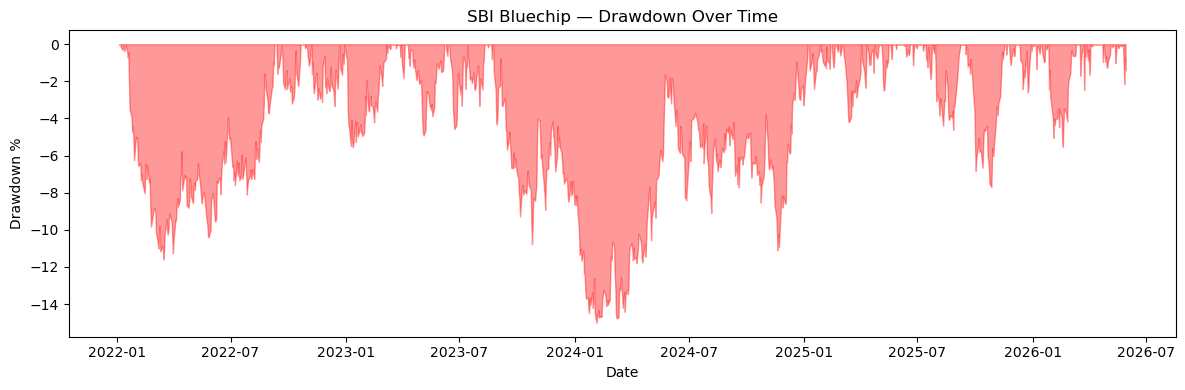

In [15]:
def max_drawdown(nav_series):
    cummax = nav_series.cummax() # Running maximum
    drawdown = nav_series / cummax - 1 # Current drop from peak
    return drawdown.min() # Worst drop (most negative)

dd = nav.groupby('amfi_code')['nav'].apply(max_drawdown).reset_index()
dd.columns = ['amfi_code', 'max_drawdown']
dd.to_csv('../data/processed/max_drawdown.csv', index=False)
# Visualise worst drawdowns
import matplotlib.pyplot as plt
# Plot drawdown over time for SBI Bluechip (119551)
sample = nav[nav['amfi_code'] == 119551].sort_values('date')
cummax = sample['nav'].cummax()
sample['drawdown'] = sample['nav'] / cummax - 1

plt.figure(figsize=(12,4))
plt.fill_between(sample['date'], sample['drawdown']*100, 0, color='red', alpha=0.4)
plt.title('SBI Bluechip — Drawdown Over Time')
plt.ylabel('Drawdown %')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../reports/drawdown_chart.png', dpi=150)
plt.show()

Task 7 — Fund Scorecard (0–100 composite score)

In [41]:
scorecard = cagr_df.merge(sharpe, on='amfi_code')
scorecard = scorecard.merge(ab_df, on='amfi_code')
scorecard = scorecard.merge(dd, on='amfi_code')

# Normalise each metric to 0-1 range
def norm(series):
    return (series - series.min()) / (series.max() - series.min())

scorecard['score_ret'] = norm(scorecard['cagr_3yr'])
scorecard['score_sha'] = norm(scorecard['sharpe_ratio'])
scorecard['score_alp'] = norm(scorecard['alpha_annual'])
scorecard['score_dd'] = norm(scorecard['max_drawdown']) # DD is negative, so higher is better
scorecard['composite_score'] = (
    scorecard['score_ret'] * 40 +
    scorecard['score_sha'] * 30 +
    scorecard['score_alp'] * 20 +
    scorecard['score_dd'] * 10
)
scorecard = scorecard.sort_values('composite_score', ascending=False)
scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
print(scorecard[['amfi_code', 'composite_score']].head(10))

    amfi_code  composite_score
34     148567        94.410020
25     120505        88.912407
30     120843        88.599190
2      100033        87.444675
16     119094        86.955262
36     148569        86.557112
19     119551        84.462886
24     120504        83.468825
38     149323        82.507685
3      101206        80.009278


In [42]:
top5_funds=scorecard.sort_values(
    'composite_score',
    ascending=False
).head(5)

In [43]:
top5_codes = top5_funds[
    'amfi_code'
].tolist()

print(top5_codes)

[148567, 120505, 120843, 100033, 119094]


In [44]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [45]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [46]:
nifty50 = benchmark[
    benchmark['index_name']
    == 'NIFTY50'
]

nifty100 = benchmark[
    benchmark['index_name']
    == 'NIFTY100'
]

In [47]:
latest_date = nav['date'].max()

start_date = latest_date - pd.DateOffset(
    years=3
)

In [48]:
nav_3yr = nav[
    nav['date'] >= start_date
]

nifty50 = nifty50[
    nifty50['date'] >= start_date
]

nifty100 = nifty100[
    nifty100['date'] >= start_date
]

In [49]:
nifty50['normalized'] = (
    nifty50['close_value']
    /
    nifty50['close_value'].iloc[0]
) * 100

In [50]:
nifty100['normalized'] = (
    nifty100['close_value']
    /
    nifty100['close_value'].iloc[0]
) * 100

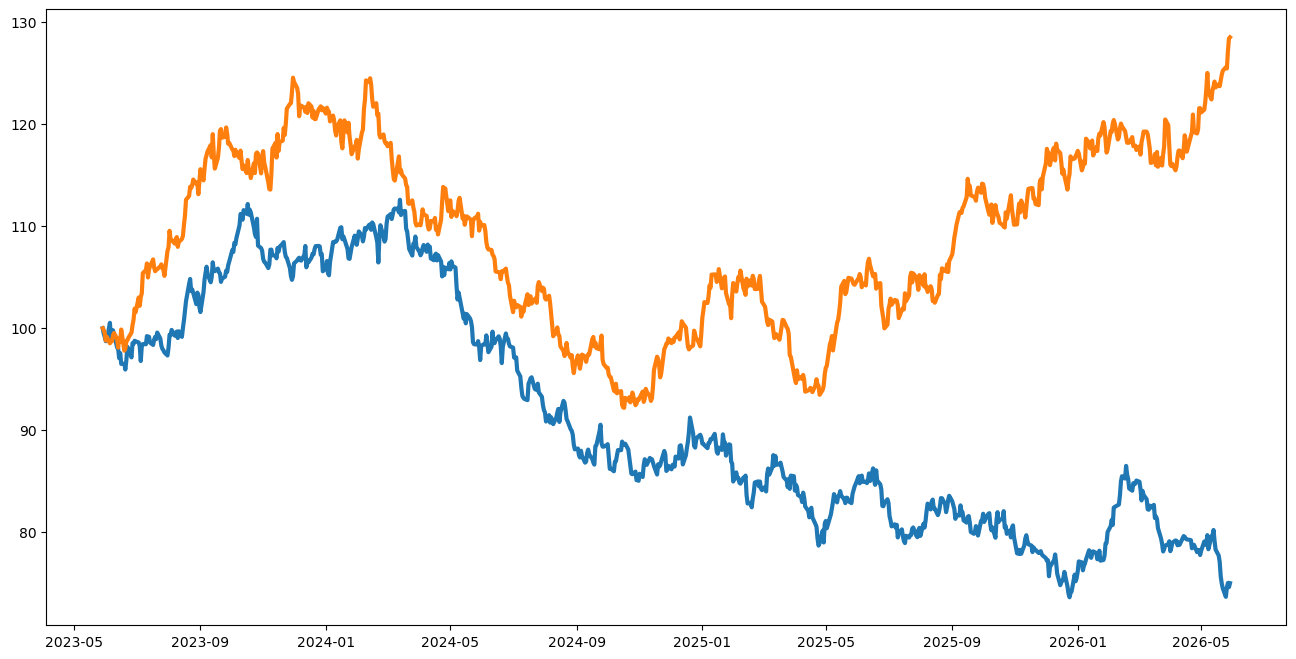

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    label='Nifty 50',
    linewidth=3
)

plt.plot(
    nifty100['date'],
    nifty100['normalized'],
    label='Nifty 100',
    linewidth=3
)

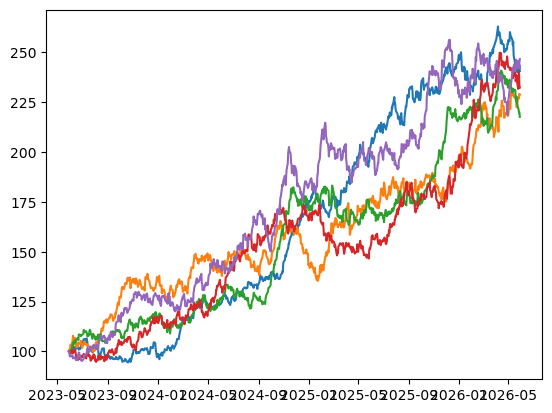

In [52]:
for code in top5_codes:

    temp = nav_3yr[
        nav_3yr['amfi_code'] == code
    ].copy()

    temp['normalized'] = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        temp['normalized'],
        label=f'Fund {code}'
    )

In [53]:
print(nifty50.shape, nifty100.shape)
print(nifty50.head(1))
print(nifty100.head(1))

(785, 4) (785, 4)
          date index_name  close_value  normalized
365 2023-05-29    NIFTY50     24688.69       100.0
           date index_name  close_value  normalized
1515 2023-05-29   NIFTY100     15324.41       100.0


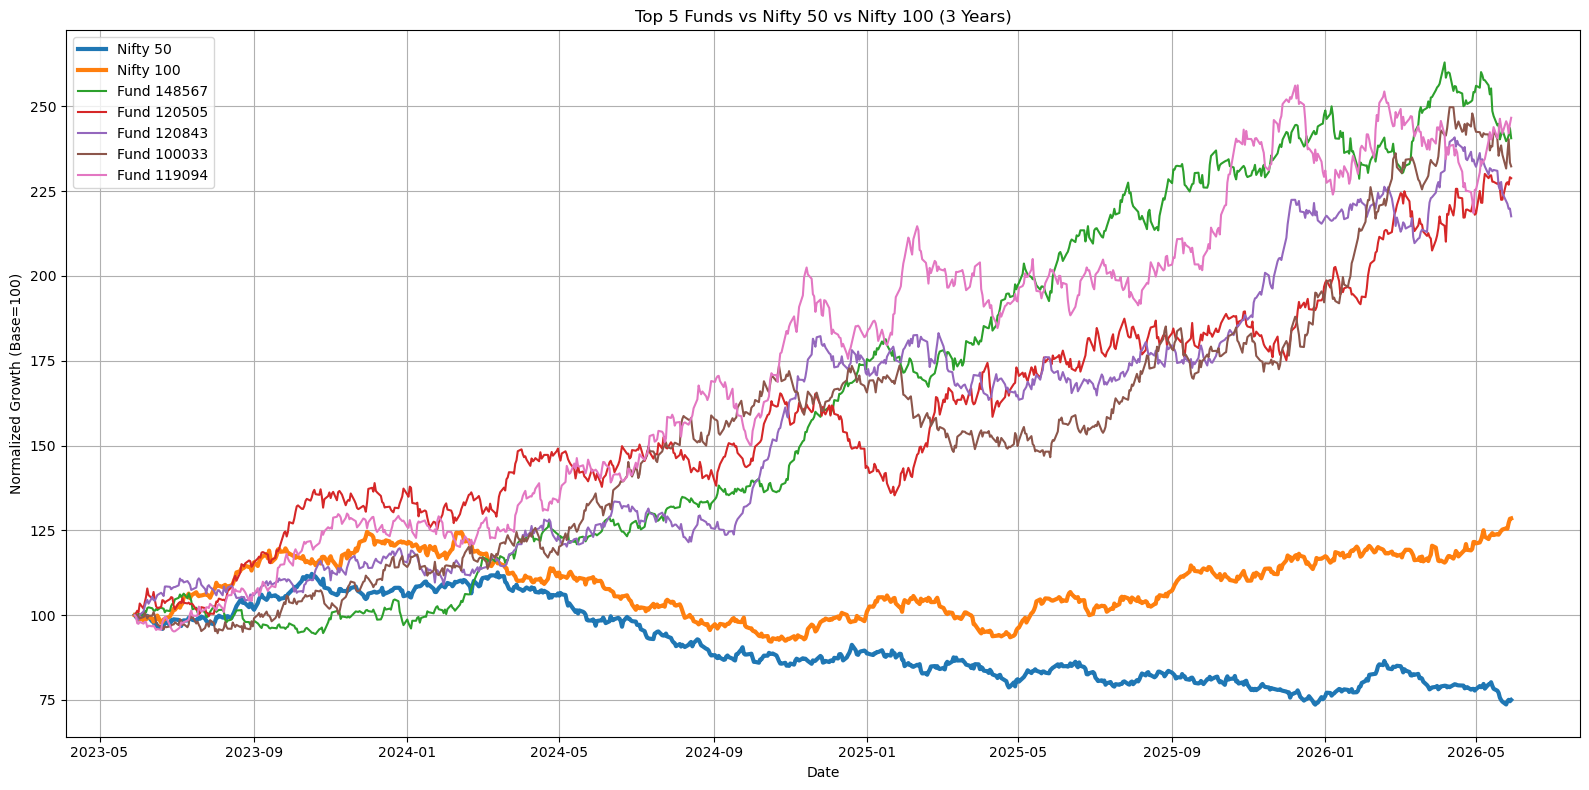

In [57]:
plt.figure(figsize=(16,8))

plt.plot(nifty50['date'], nifty50['normalized'], label='Nifty 50', linewidth=3)
plt.plot(nifty100['date'], nifty100['normalized'], label='Nifty 100', linewidth=3)

for code in top5_codes:
    temp = nav_3yr[nav_3yr['amfi_code'] == code].copy()
    temp['normalized'] = temp['nav'] / temp['nav'].iloc[0] * 100
    plt.plot(temp['date'], temp['normalized'], label=f'Fund {code}')

plt.title("Top 5 Funds vs Nifty 50 vs Nifty 100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('../reports/benchmark_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
fund = nav[
    nav['amfi_code']
    == top5_codes[0]
].copy()

In [59]:
fund['return'] = (
    fund['nav']
    .pct_change()
)

In [61]:
nifty100['return'] = (
    nifty100['close_value']
    .pct_change()
)

In [62]:
merged = pd.merge(
    fund[['date','return']],
    nifty100[['date','return']],
    on='date',
    suffixes=(
        '_fund',
        '_benchmark'
    )
)

In [63]:
tracking_error = (

    (
        merged['return_fund']
        -
        merged['return_benchmark']
    )

    .std()

    * np.sqrt(252)

)

print(
    f"Tracking Error = {tracking_error:.4f}"
)

Tracking Error = 0.1880


Observation for Benchmark Chart:

### Observation

Trend:
- Most top-ranked funds outperformed the benchmark indices over the 3-year period.

Anomaly:
- Certain funds experienced periods of underperformance during market corrections.

Insight:
- Funds with higher alpha generated returns above benchmark expectations, while lower tracking error indicates closer benchmark alignment.